基于GA的JSP调度实现

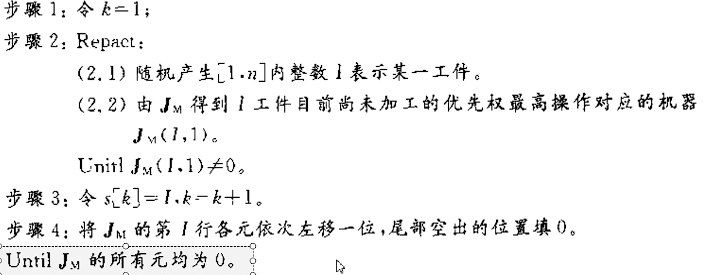

In [2]:
import numpy as np

def createInd(J):
  '''
  初始化操作，从1开始
  '''
  n = J.shape[0]
  s = []
  Jm = J.copy()
  while not np.all(Jm == 0):
    I = np.random.randint(0,n)
    M = Jm[I, 0]
    if M != 0:
      s.append(I)
      b = np.roll(Jm[I, :], -1)
      b[-1] = 0
      Jm[I,:] = b
  return s

def createPop(Jm, popSize):
  pop = []
  for i in range(popSize):
    pop.append(createInd(Jm))
  return pop

In [3]:

J=np.array([[1,2,3],[2,1,3],[3,1,2]])
P=np.array([[2,1,3],[3,3,2],[2,2,2]])
n,m=J.shape
popSize=2


In [4]:
createPop(J, popSize)

[[0, 2, 2, 2, 1, 0, 0, 1, 1], [2, 2, 2, 1, 0, 0, 0, 1, 1]]

In [5]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import copy

def choice(fitness, k=3, pool=None):
    '''
    锦标赛选择
    fitness: 适应度列表（越小越好）
    k: 每次选择的个体数
    pool: 选择池大小
    '''
    if pool is None:
        pool = len(fitness)
    n = len(fitness)
    choice_index = []
    for _ in range(pool):
        random_indices = random.sample(range(n), k)
        min_idx = random_indices[0]
        for idx in random_indices[1:]:
            if fitness[idx] < fitness[min_idx]:
                min_idx = idx
        choice_index.append(min_idx)
    return choice_index

def crossover(parent1, parent2):
    '''
    POX交叉（基于工序的交叉）
    选择父代1的一个工序子集S1，将S1中的工序保持位置遗传给子代1，
    其余位置按父代2中非S1工序的顺序填充
    '''
    n = max(parent1) + 1
    chrom_len = len(parent1)
    job_set = list(range(n))
    num_extract = random.randint(1, n - 1)
    S1 = set(random.sample(job_set, num_extract))
    
    # 子代1
    child1 = [None] * chrom_len
    temp_p2 = [item for item in parent2 if item not in S1]
    idx2 = 0
    for i in range(chrom_len):
        if parent1[i] in S1:
            child1[i] = parent1[i]
        else:
            child1[i] = temp_p2[idx2]
            idx2 += 1

    # 子代2
    child2 = [None] * chrom_len
    temp_p1 = [item for item in parent1 if item not in S1]
    idx2 = 0
    for i in range(chrom_len):
        if parent2[i] in S1:
            child2[i] = parent2[i]
        else:
            child2[i] = temp_p1[idx2]
            idx2 += 1
    
    return child1, child2

def mutation(chromosome, pm=0.1):
    '''
    变异操作：以概率pm对染色体进行逆序变异
    随机选择两个位置，将中间的子序列反转
    '''
    if random.random() < pm:
        mutant = chromosome.copy()
        idx1, idx2 = random.sample(range(len(mutant)), 2)
        rl, rr = min(idx1, idx2), max(idx1, idx2)
        mutant[rl:rr] = mutant[rl:rr][::-1]
        return mutant
    return chromosome.copy()

def decode(chromosome, J, P):
    '''
    解码：将染色体（工序序列）解码为调度方案
    chromosome: 操作序列，每个job编号出现次数等于其工序数
    J: 工序-机器矩阵 (n x m)，值表示机器编号（从1开始）
    P: 工序-时间矩阵 (n x m)，值表示加工时间
    返回: schedule列表[(job, op_idx, machine, start_time, end_time)], makespan
    '''
    n = J.shape[0]
    job_step = [0] * n              # 每个job当前工序索引
    job_end_time = [0] * n          # 每个job的最后完成时间
    machine_num = J.max()           # 机器数量
    machine_end_time = [0] * machine_num  # 每台机器的最后完成时间
    schedule = []
    
    for job in chromosome:
        op_idx = job_step[job]
        machine = J[job, op_idx] - 1  # 转为0-indexed
        p_time = P[job, op_idx]
        start_time = max(job_end_time[job], machine_end_time[machine])
        end_time = start_time + p_time
        schedule.append((job, op_idx, machine, start_time, end_time))
        job_step[job] += 1
        job_end_time[job] = end_time
        machine_end_time[machine] = end_time

    makespan = max(job_end_time)
    return schedule, makespan

In [6]:
def draw_gantt(schedule, J, P, title="Gantt Chart"):
    '''
    绘制甘特图
    schedule: decode函数返回的调度方案
    J: 工序-机器矩阵
    P: 工序-时间矩阵
    '''
    n = J.shape[0]
    machine_num = J.max()
    colors = plt.cm.tab10(np.linspace(0, 1, n))
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # 按机器分组
    machine_ops = {i: [] for i in range(machine_num)}
    for job, op_idx, machine, start, end in schedule:
        machine_ops[machine].append((job, op_idx, start, end))
    
    # 绘制每个机器上的工序
    for machine in range(machine_num):
        for job, op_idx, start, end in machine_ops[machine]:
            ax.barh(machine, end - start, left=start, height=0.6,
                    color=colors[job], edgecolor='black', linewidth=1)
            ax.text((start + end) / 2, machine, f'J{job}O{op_idx}',
                    ha='center', va='center', fontsize=9, fontweight='bold')
    
    ax.set_yticks(range(machine_num))
    ax.set_yticklabels([f'M{i+1}' for i in range(machine_num)])
    ax.set_xlabel('Time', fontsize=12)
    ax.set_ylabel('Machine', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.grid(axis='x', alpha=0.3)
    
    # 图例
    patches = [mpatches.Patch(color=colors[i], label=f"Job {i}") for i in range(n)]
    ax.legend(handles=patches, loc='upper right')
    
    plt.tight_layout()
    plt.show()

def print_schedule(schedule):
    '''打印调度方案'''
    print("Job | Op | Machine | Start | End")
    print("---" * 8)
    for job, op_idx, machine, start, end in schedule:
        print(f" J{job} | {op_idx} |   M{machine+1}  |  {start:.0f}  | {end:.0f}")
    makespan = max(end for _, _, _, _, end in schedule)
    print(f"\nMakespan = {makespan}")

In [7]:
def GA_JSP(J, P, popSize=50, generations=100, pc=0.8, pm=0.1):
    '''
    GA求解JSP主函数
    J: 工序-机器矩阵 (n x m)
    P: 工序-时间矩阵 (n x m)
    popSize: 种群大小
    generations: 迭代代数
    pc: 交叉概率
    pm: 变异概率
    返回: (best_chromosome, best_makespan, best_schedule)
    '''
    n = J.shape[0]
    m = J.shape[1]
    print(f"JSP实例: {n}个Job, {m}道工序, {J.max()}台机器")
    
    # 初始化种群
    pop = createPop(J, popSize)
    
    best_makespan = float('inf')
    best_chromosome = None
    best_schedule = None
    best_history = []
    
    for gen in range(generations):
        # 解码并计算适应度
        fitness = []
        schedules = []
        for chrom in pop:
            schedule, makespan = decode(chrom, J, P)
            fitness.append(makespan)
            schedules.append(schedule)
        
        # 记录当前代最优
        min_idx = int(np.argmin(fitness))
        gen_best = fitness[min_idx]
        best_history.append(gen_best)
        
        if gen_best < best_makespan:
            best_makespan = gen_best
            best_chromosome = pop[min_idx].copy()
            best_schedule = schedules[min_idx]
        
        # 锦标赛选择
        selected_idx = choice(fitness, k=3, pool=popSize)
        selected_chroms = [pop[i] for i in selected_idx]
        
        # 交叉产生新种群
        new_pop = []
        i = 0
        while i < popSize:
            if i + 1 < popSize and random.random() < pc:
                c1, c2 = crossover(selected_chroms[i], selected_chroms[i+1])
                new_pop.append(c1)
                new_pop.append(c2)
            else:
                new_pop.append(selected_chroms[i].copy())
            i += 1
        
        # 变异
        for i in range(len(new_pop)):
            new_pop[i] = mutation(new_pop[i], pm)
        
        pop = new_pop
        
        # 输出进度
        if (gen + 1) % 20 == 0 or gen == 0:
            print(f"Generation {gen+1:4d}: Best = {gen_best:3d}, Global Best = {best_makespan:3d}")
    
    print(f"\nFinal Results:")
    print(f"Best Makespan = {best_makespan}")
    print(f"Best Chromosome = {best_chromosome}")
    
    # 绘制收敛曲线
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    ax1.plot(best_history, 'b-', linewidth=1.5)
    ax1.set_xlabel('Generation')
    ax1.set_ylabel('Makespan')
    ax1.set_title('Convergence Curve')
    ax1.grid(alpha=0.3)
    
    # 绘制甘特图
    draw_gantt(best_schedule, J, P, title=f"Best Schedule (Makespan={best_makespan})")
    
    print_schedule(best_schedule)
    
    return best_chromosome, best_makespan, best_schedule

Job数量: 6, 工序数量: 6, 机器数量: 6
J (机器序列):
[[3 1 2 4 6 5]
 [2 3 5 6 1 4]
 [3 4 6 1 2 5]
 [2 1 3 4 5 6]
 [3 2 5 6 1 4]
 [2 4 6 1 5 3]]
P (加工时间):
[[ 1  3  6  7  3  6]
 [ 8  5 10 10 10  4]
 [ 5  4  8  9  1  7]
 [ 5  5  5  3  8  9]
 [ 9  3  5  4  3  1]
 [ 3  3  9 10  4  1]]
JSP实例: 6个Job, 6道工序, 6台机器
Generation    1: Best =  70, Global Best =  70
Generation   20: Best =  57, Global Best =  57
Generation   40: Best =  57, Global Best =  57
Generation   60: Best =  57, Global Best =  57
Generation   80: Best =  57, Global Best =  57
Generation  100: Best =  57, Global Best =  57

Final Results:
Best Makespan = 57
Best Chromosome = [5, 2, 0, 1, 1, 1, 2, 0, 2, 0, 3, 4, 2, 3, 5, 0, 5, 2, 0, 3, 4, 5, 3, 2, 4, 1, 1, 1, 3, 4, 5, 4, 3, 0, 4, 5]


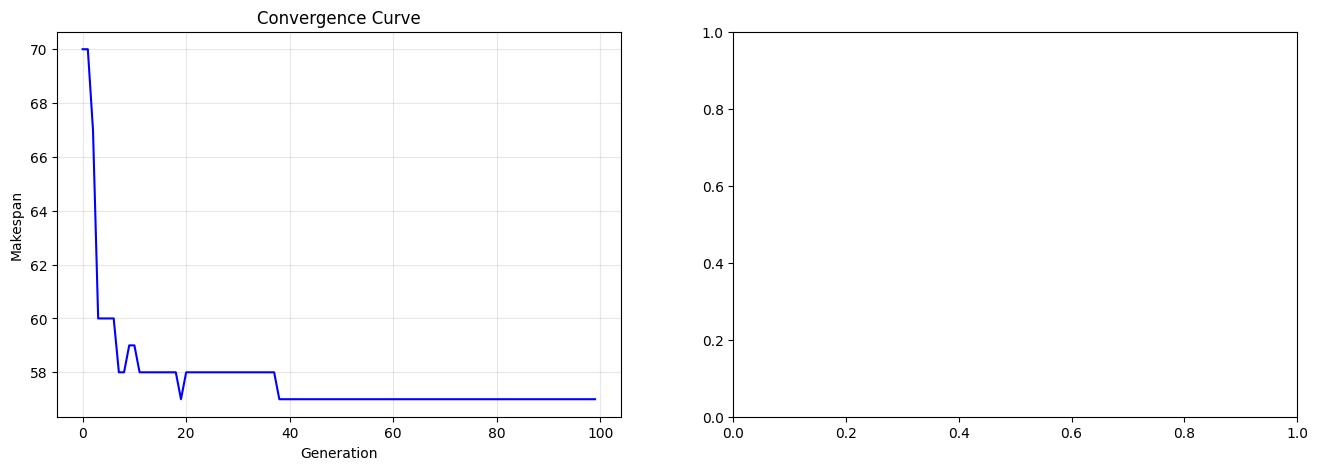

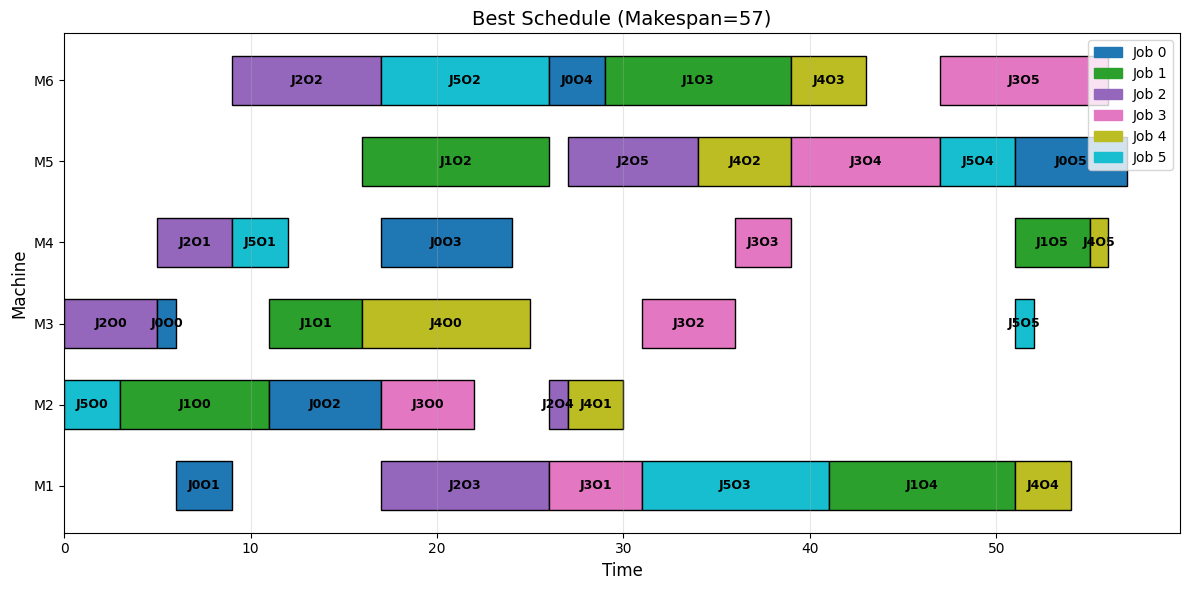

Job | Op | Machine | Start | End
------------------------
 J5 | 0 |   M2  |  0  | 3
 J2 | 0 |   M3  |  0  | 5
 J0 | 0 |   M3  |  5  | 6
 J1 | 0 |   M2  |  3  | 11
 J1 | 1 |   M3  |  11  | 16
 J1 | 2 |   M5  |  16  | 26
 J2 | 1 |   M4  |  5  | 9
 J0 | 1 |   M1  |  6  | 9
 J2 | 2 |   M6  |  9  | 17
 J0 | 2 |   M2  |  11  | 17
 J3 | 0 |   M2  |  17  | 22
 J4 | 0 |   M3  |  16  | 25
 J2 | 3 |   M1  |  17  | 26
 J3 | 1 |   M1  |  26  | 31
 J5 | 1 |   M4  |  9  | 12
 J0 | 3 |   M4  |  17  | 24
 J5 | 2 |   M6  |  17  | 26
 J2 | 4 |   M2  |  26  | 27
 J0 | 4 |   M6  |  26  | 29
 J3 | 2 |   M3  |  31  | 36
 J4 | 1 |   M2  |  27  | 30
 J5 | 3 |   M1  |  31  | 41
 J3 | 3 |   M4  |  36  | 39
 J2 | 5 |   M5  |  27  | 34
 J4 | 2 |   M5  |  34  | 39
 J1 | 3 |   M6  |  29  | 39
 J1 | 4 |   M1  |  41  | 51
 J1 | 5 |   M4  |  51  | 55
 J3 | 4 |   M5  |  39  | 47
 J4 | 3 |   M6  |  39  | 43
 J5 | 4 |   M5  |  47  | 51
 J4 | 4 |   M1  |  51  | 54
 J3 | 5 |   M6  |  47  | 56
 J0 | 5 |   M5  |  51  | 57
 J4

In [8]:
# 运行GA求解JSP示例
J = np.array([
    [3, 1, 2, 4, 6, 5],   # Job 0: M3(1) M1(3) M2(6) M4(7) M6(3) M5(6)
    [2, 3, 5, 6, 1, 4],   # Job 1: M2(8) M3(5) M5(10) M6(10) M1(10) M4(4)
    [3, 4, 6, 1, 2, 5],   # Job 2: M3(5) M4(4) M6(8) M1(9) M2(1) M5(7)
    [2, 1, 3, 4, 5, 6],   # Job 3: M2(5) M1(5) M3(5) M4(3) M5(8) M6(9)
    [3, 2, 5, 6, 1, 4],   # Job 4: M3(9) M2(3) M5(5) M6(4) M1(3) M4(1)
    [2, 4, 6, 1, 5, 3]    # Job 5: M2(3) M4(3) M6(9) M1(10) M5(4) M3(1)
])
P = np.array([
    [1, 3, 6, 7, 3, 6],
    [8, 5, 10, 10, 10, 4],
    [5, 4, 8, 9, 1, 7],
    [5, 5, 5, 3, 8, 9],
    [9, 3, 5, 4, 3, 1],
    [3, 3, 9, 10, 4, 1]
])
n, m = J.shape
print(f"Job数量: {n}, 工序数量: {m}, 机器数量: {J.max()}")
print(f"J (机器序列):\n{J}")
print(f"P (加工时间):\n{P}")

# 运行GA
best_chromosome, best_makespan, best_schedule = GA_JSP(
    J, P,
    popSize=50,
    generations=100,
    pc=0.8,
    pm=0.1
)